# Part 1 – Visualization
**Group 2 · Season 2023 (January 1 to May 31)**

Between January and May 2023, heavy rains affected Peru, and as a result the national government declared states of emergency in numerous departments. In Assignment 2, we collected two pieces of information for each department, namely the number of **emergency declarations** it received, which were scraped from the legal norms published on gob.pe, and the amount of **rainfall** it recorded, which was obtained from the Open-Meteo historical weather API. Both sources were subsequently merged into a single table, `tabla_final.csv`.

Building on this table, the present notebook addresses the following question. **Does the State declare emergencies where it rains the most?**

Since tables alone rarely communicate patterns effectively, the question is explored through interactive charts built with **Plotly Express**. First, a bar chart ranks departments by the number of declarations they received. Second, a scatter plot examines the relationship between rainfall and declarations. Third, a histogram describes how unequally rainfall was distributed across the country. Subsequently, a quick check verifies that the charts are consistent with the values in the table. Finally, two additional analyses are presented, the first identifying the departments that received more rain but fewer declarations, and the second showing when the declarations were published throughout the season.

In [5]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Render every chart twice: interactive for Jupyter and a static PNG,
# so the charts are also visible on GitHub (same as in Assignment 2).
pio.renderers.default = "plotly_mimetype+png"

## 1. Load the data

In [6]:
tabla = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})

tabla.shape

(25, 9)

In [7]:
tabla.head()

,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte,capital,latitud,longitud
0,01,Amazonas,3,1,414.6,3,Chachapoyas,-6.23169,-77.86903
1,02,Áncash,6,1,1145.8,9,Huaraz,-9.52614,-77.52869
2,03,Apurímac,1,0,726.2,3,Abancay,-13.63426,-72.88380
3,04,Arequipa,4,0,362.0,1,Arequipa,-16.39899,-71.53747
4,05,Ayacucho,5,1,498.4,2,Ayacucho,-13.16380,-74.22345


## 2. Research question and variables

The analysis is guided by a single research question, **does the State declare emergencies where it rains the most?** In order to answer it, four columns from `tabla_final.csv` are used, which are described in the table below.

| Column | Description |
|---|---|
| `departamento` | Name of the department |
| `declaratorias` | Number of emergency declarations due to rain between January and May 2023 |
| `lluvia_total_mm` | Total rainfall during the season, in millimeters, measured at the department capital |
| `dias_lluvia_fuerte` | Number of days with 20 mm of rain or more |

The emergency declarations were obtained from the legal norms of the Presidency of the Council of Ministers (PCM) published on gob.pe, which were scraped in Assignment 2. Meanwhile, rainfall data come from the Open-Meteo historical weather API.

It should be noted that each row of the table summarizes one department over the entire season. Therefore, the data allow departments to be compared with one another, but not days within the season, since Assignment 2 stored only the **total** rainfall of each department rather than its daily values. For this reason, it is not possible to measure how many days the State took to declare an emergency after the rain intensified. Instead, the analysis can only show the **month** in which each decree was published, which is presented in the second additional analysis.

In [8]:
fuente = "Source: PCM emergency decrees (gob.pe) and Open-Meteo, Jan-May 2023. Own elaboration."

## 3. Emergency declarations by department (bar chart)

In order to compare the number of emergency declarations across departments, a horizontal bar chart was used, since department names are long and can therefore be read more easily along the vertical axis. Moreover, the bars were sorted from lowest to highest, so that the ranking can be identified at a glance, and the exact value was displayed at the end of each bar in order to avoid relying on the gridlines.

As the chart shows, Áncash and Lima received the most declarations between January and May 2023, with 6 each, followed by Ayacucho and La Libertad, with 5 each. In contrast, Madre de Dios did not receive any declaration during the season. This last result is particularly striking, given that it is one of the departments with the highest rainfall, as will be shown in the following section.

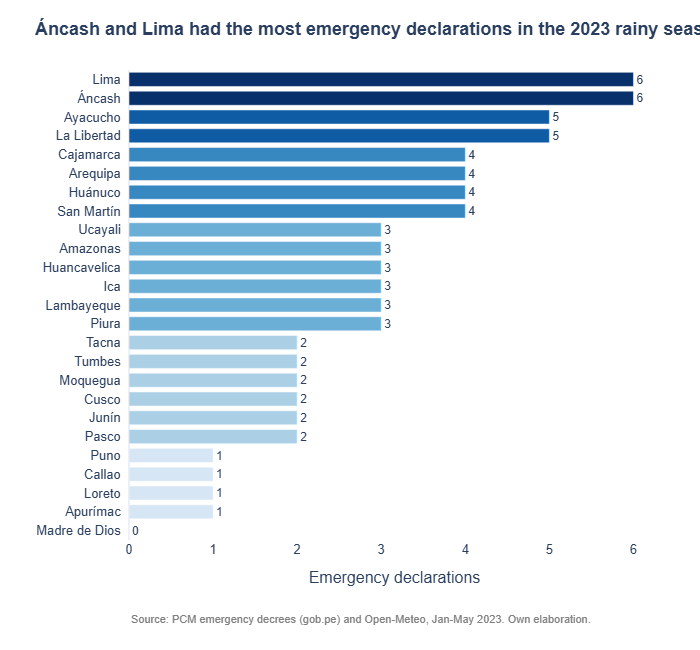

In [11]:
fig = px.bar(tabla.sort_values("declaratorias"),
             x="declaratorias", y="departamento", orientation="h",
             color="declaratorias", color_continuous_scale="Blues",
             text="declaratorias",
             labels={"declaratorias": "Emergency declarations", "departamento": ""},
             title="<b>Áncash and Lima had the most emergency declarations in the 2023 rainy season</b>",
             height=650)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_layout(
    coloraxis_showscale=False,
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    bargap=0.25,
    margin=dict(l=10, r=40, t=70, b=110),
    xaxis=dict(showgrid=False),
    yaxis=dict(ticksuffix="  "),
    annotations=[dict(
        text=fuente, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()

## 4. Rainfall and emergency declarations (scatter plot)

In order to examine the relationship between two numerical variables, a scatter plot was used, in which each point represents a department. Its horizontal position corresponds to the total rainfall recorded between January and May 2023, whereas its vertical position indicates the number of emergency declarations it received. In addition, the color introduces a third variable, namely the number of days with heavy rain (20 mm or more), so that darker blues represent a greater number of such days. Accordingly, if the State declared emergencies where it rains the most, the points would be expected to rise from left to right.

However, the chart does not show this pattern. On the one hand, Loreto, Ucayali and Madre de Dios recorded the highest rainfall and the most days of heavy rain, yet they received between 0 and 3 declarations. On the other hand, Lima received 6 declarations despite recording only 55 mm. Nevertheless, these results should be interpreted with caution, given that rainfall was measured at a single point in each department (its capital). Consequently, the comparison reflects conditions in the capitals rather than across entire territories.

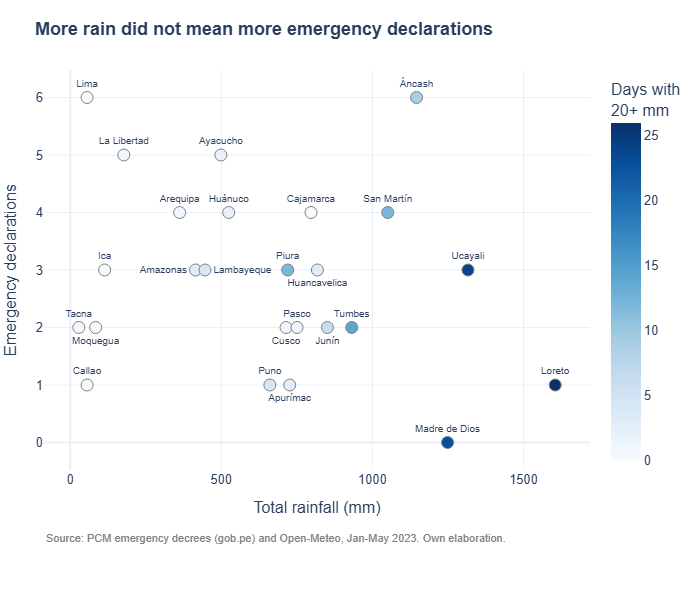

In [25]:
# Labels that overlap go below the point; the rest stay above
abajo = ["Moquegua", "Apurímac", "Cusco", "Junín", "Huancavelica"]
posicion = ["bottom center" if d in abajo else "top center" for d in tabla["departamento"]]

# Two neighbors that need extra space
posicion[tabla.index[tabla["departamento"] == "Amazonas"][0]] = "middle left"
posicion[tabla.index[tabla["departamento"] == "Lambayeque"][0]] = "middle right"

fig = px.scatter(tabla, x="lluvia_total_mm", y="declaratorias",
                 hover_name="departamento", text="departamento",
                 color="dias_lluvia_fuerte", color_continuous_scale="Blues",
                 labels={"lluvia_total_mm": "Total rainfall (mm)",
                         "declaratorias": "Emergency declarations",
                         "dias_lluvia_fuerte": "Days with<br>20+ mm"},
                 title="<b>More rain did not mean more emergency declarations</b>",
                 height=600)
fig.update_traces(textposition=posicion, textfont_size=10,
                  marker=dict(size=12, line=dict(width=1, color="gray")))
fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    margin=dict(l=10, r=40, t=70, b=130),
    annotations=[dict(
        text=fuente, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()
fig_dispersion = fig

In [17]:
tabla[["lluvia_total_mm", "declaratorias"]].corr()

,lluvia_total_mm,declaratorias
lluvia_total_mm,1.000000,-0.217649
declaratorias,-0.217649,1.000000


In order to confirm numerically what the scatter plot suggests, the Pearson correlation coefficient between total rainfall and the number of emergency declarations was calculated. This coefficient ranges from -1 to 1, where values close to 1 indicate that both variables increase together, values close to 0 indicate no linear relationship, and values close to -1 indicate that one variable decreases as the other increases. The result, -0.22, reveals a weak and slightly negative relationship. Therefore, departments with more rainfall did not receive more declarations. Nevertheless, this value should not be read as evidence that more rain leads to fewer declarations, given that it is close to zero and is based on only 25 departments.

## 5. Distribution of rainfall across departments (histogram)

In order to describe how rainfall was distributed across the country, a histogram was used, which groups departments into ranges of total rainfall and counts how many fall within each range. Unlike the previous charts, this one does not compare departments individually, but rather shows the overall shape of the distribution.

As the chart shows, rainfall during the 2023 season was highly unequal. On the one hand, six departments, most of them on the arid coast such as Tacna, Lima and Ica, recorded less than 200 mm. On the other hand, five departments, mainly in the Amazon such as Loreto, Ucayali and Madre de Dios, exceeded 1,000 mm. This contrast is relevant to our question, given that the coastal departments received many declarations despite their low rainfall.

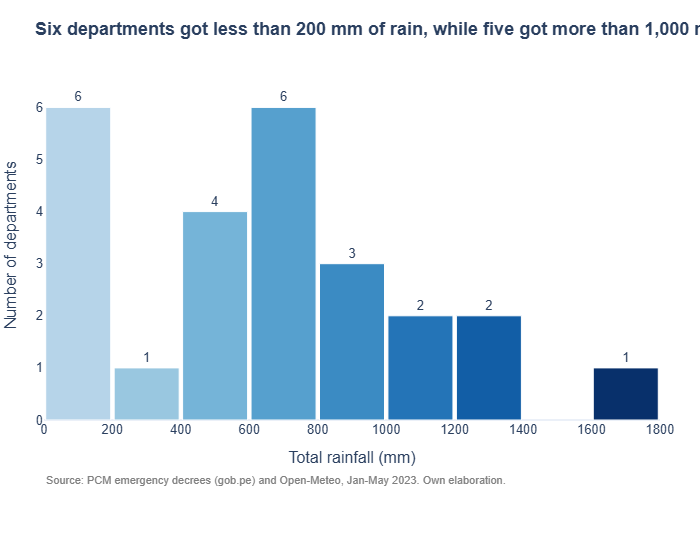

In [19]:
# One color per rainfall range: light blue = little rain, dark blue = a lot
cortes = list(range(0, 2000, 200))
etiquetas = [f"{c}-{c + 200}" for c in cortes[:-1]]
tabla["rango"] = pd.cut(tabla["lluvia_total_mm"], bins=cortes, labels=etiquetas).astype(str)
colores = px.colors.sample_colorscale("Blues", [0.3 + 0.7 * i / 8 for i in range(9)])

fig = px.histogram(tabla, x="lluvia_total_mm", color="rango", text_auto=True,
                   category_orders={"rango": etiquetas},
                   color_discrete_sequence=colores,
                   labels={"lluvia_total_mm": "Total rainfall (mm)"},
                   title="<b>Six departments got less than 200 mm of rain, while five got more than 1,000 mm</b>",
                   height=550)
fig.update_traces(xbins=dict(start=0, end=1800, size=200),
                  marker_line=dict(width=1, color="white"),
                  textposition="outside", cliponaxis=False)
fig.update_layout(
    showlegend=False,
    yaxis_title="Number of departments",
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    bargap=0.05,
    margin=dict(l=10, r=40, t=70, b=130),
    xaxis=dict(dtick=200),
    yaxis=dict(showgrid=False),
    annotations=[dict(
        text=fuente, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()

In [20]:
(tabla["lluvia_total_mm"] < 200).sum(), (tabla["lluvia_total_mm"] > 1000).sum()

(np.int64(6), np.int64(5))

## 6. Verification of extreme values

Since a chart can be misleading if the data were read or processed incorrectly, the highest and lowest values in the table were checked against what the charts display. For this purpose, the three departments with the most and the fewest declarations, as well as the three with the highest and the lowest rainfall, were extracted directly from the table.

In [21]:
tabla.nlargest(3, "declaratorias")[["departamento", "declaratorias"]]

,departamento,declaratorias
1,Áncash,6
14,Lima,6
4,Ayacucho,5


In [22]:
tabla.nsmallest(3, "declaratorias")[["departamento", "declaratorias"]]

,departamento,declaratorias
16,Madre de Dios,0
2,Apurímac,1
6,Callao,1


In [23]:
tabla.nlargest(3, "lluvia_total_mm")[["departamento", "lluvia_total_mm"]]

,departamento,lluvia_total_mm
15,Loreto,1604.6
24,Ucayali,1316.0
16,Madre de Dios,1248.4


In [24]:
tabla.nsmallest(3, "lluvia_total_mm")[["departamento", "lluvia_total_mm"]]

,departamento,lluvia_total_mm
22,Tacna,28.2
6,Callao,55.5
14,Lima,55.5


The extreme values extracted from the table are consistent with the charts. Regarding emergency declarations, Áncash and Lima (6 each) appear as the longest bars at the top of the bar chart, whereas Madre de Dios (0) appears at the bottom without a bar. Ayacucho is listed third because, when values are tied, pandas keeps the order of the original table, although La Libertad also received 5 declarations. Regarding rainfall, Loreto (1,604.6 mm) is the point furthest to the right in the scatter plot and the only department in the last bar of the histogram, while Tacna (28.2 mm) is the point furthest to the left. Callao and Lima share the same value (55.5 mm) because their capitals fall within the same grid cell of the Open-Meteo model. Therefore, the charts accurately reflect the data.

## 7. Exporting a chart to HTML

The scatter plot was exported as an HTML file, since it is the chart that most directly addresses the research question. Unlike a static image, this file can be opened in any web browser and remains interactive, so that readers can hover over each point to identify the department without needing Python.

In [26]:
fig_dispersion.write_html("grafico.html", include_plotlyjs="cdn")
print("Saved. Open grafico.html with a double click.")

Saved. Open grafico.html with a double click.


## 8. Additional analysis 1. Departments with more rain but fewer declarations

In order to identify the departments where the response of the State did not match the intensity of the rain, the departments were classified into groups using the median of each variable, that is, the value that leaves half of the departments above and half below. The median was preferred over the mean because a few departments, such as Loreto, recorded far more rainfall than the rest and would therefore pull the mean upwards. Accordingly, a department is considered to have "more rain, fewer declarations" when its rainfall is above the median (714 mm) and its number of declarations is below the median (3).

As a result, six departments fall into this group, namely Loreto, Madre de Dios, Tumbes, Junín, Pasco and Apurímac. Conversely, eight departments, including Lima, Ica and La Libertad, received at least the median number of declarations despite recording rainfall at or below the median. These findings reinforce the conclusion of the scatter plot, given that the departments with the greatest rainfall were not necessarily those that received the most declarations.

In [27]:
lluvia_mediana = tabla["lluvia_total_mm"].median()
decl_mediana = tabla["declaratorias"].median()

def clasificar(fila):
    if fila["lluvia_total_mm"] > lluvia_mediana and fila["declaratorias"] < decl_mediana:
        return "More rain, fewer declarations"
    elif fila["lluvia_total_mm"] <= lluvia_mediana and fila["declaratorias"] >= decl_mediana:
        return "Less rain, more declarations"
    else:
        return "As expected"

tabla["grupo"] = tabla.apply(clasificar, axis=1)

lluvia_mediana, decl_mediana

(np.float64(714.0), np.float64(3.0))

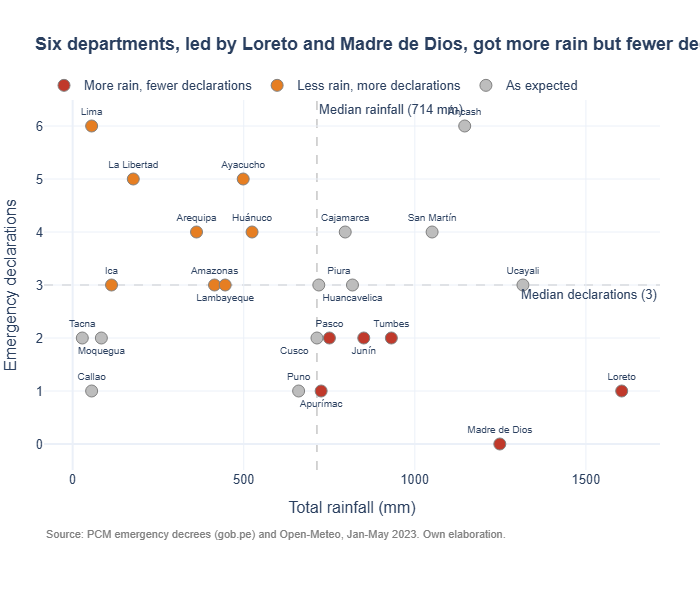

In [30]:
fig = px.scatter(tabla, x="lluvia_total_mm", y="declaratorias",
                 hover_name="departamento", text="departamento", color="grupo",
                 color_discrete_map={"More rain, fewer declarations": "#c0392b",
                                     "Less rain, more declarations": "#e67e22",
                                     "As expected": "#bdbdbd"},
                 category_orders={"grupo": ["More rain, fewer declarations",
                                            "Less rain, more declarations",
                                            "As expected"]},
                 labels={"lluvia_total_mm": "Total rainfall (mm)",
                         "declaratorias": "Emergency declarations",
                         "grupo": ""},
                 title="<b>Six departments, led by Loreto and Madre de Dios, got more rain but fewer declarations</b>",
                 height=600)

# Reuse the label positions from the scatter plot so names do not overlap
posiciones = dict(zip(tabla["departamento"], posicion))

# Move the labels that sit on the median lines
posiciones["Amazonas"] = "top center"
posiciones["Lambayeque"] = "bottom center"
posiciones["Piura"] = "top right"
posiciones["Cusco"] = "bottom left"

for trazo in fig.data:
    trazo.textposition = [posiciones[d] for d in trazo.hovertext]

fig.add_vline(x=lluvia_mediana, line_dash="dash", line_width=1, line_color="darkgray",
              layer="below",
              annotation_text="Median rainfall (714 mm)", annotation_position="top right")
fig.add_hline(y=decl_mediana, line_dash="dash", line_width=1, line_color="darkgray",
              layer="below",
              annotation_text="Median declarations (3)", annotation_position="bottom right")
fig.update_traces(textfont_size=10, marker=dict(size=12, line=dict(width=1, color="gray")))
fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    legend=dict(orientation="h", y=1.08, x=0),
    margin=dict(l=10, r=40, t=100, b=130),
    annotations=list(fig.layout.annotations) + [dict(
        text=fuente, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()

In [31]:
tabla[tabla["grupo"] == "More rain, fewer declarations"].sort_values("lluvia_total_mm", ascending=False)[
    ["departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias"]]

,departamento,lluvia_total_mm,dias_lluvia_fuerte,declaratorias
15,Loreto,1604.6,26,1
16,Madre de Dios,1248.4,23,0
23,Tumbes,931.4,14,2
11,Junín,850.8,6,2
18,Pasco,750.4,1,2
2,Apurímac,726.2,3,1


## 9. Additional analysis 2. Emergency decrees by month and reason

Although the data do not allow us to measure how many days the State took to declare an emergency, the file `decretos_lluvias.csv` from Assignment 2 records the publication date of each of the 20 emergency decrees issued during the season, as well as the reason stated in each one. It should be noted that a single decree usually covers several departments, which is why there are 20 decrees but 72 department-level declarations in `tabla_final.csv`. The decrees were therefore grouped by month and classified according to their reason. On the one hand, decrees issued for "imminent danger" were published before the damage occurred and can be regarded as preventive. On the other hand, decrees issued for "damage already occurred" were published as a reaction once the damage had taken place.

As the chart shows, March concentrated the largest number of decrees (9), which coincides with the peak of the rainy season. More importantly, only 3 of the 20 decrees were preventive, whereas 15 were issued after the damage had occurred. This suggests that the response of the State was mainly reactive rather than anticipatory.

In [32]:
decretos = pd.read_csv("datos/decretos_lluvias.csv", encoding="utf-8-sig")

# Take the month name from "Publicado: 13 de enero de 2023" and translate it
meses = {"enero": "January", "febrero": "February", "marzo": "March",
         "abril": "April", "mayo": "May"}
decretos["mes"] = decretos["fecha"].str.extract(r"de (\w+) de")[0].map(meses)

# Translate the reason of each decree for the chart
motivos = {"peligro inminente": "Imminent danger (before the damage)",
           "impacto de daños": "Damage already occurred",
           "otro": "Other"}
decretos["motivo_en"] = decretos["motivo"].map(motivos)

por_mes = decretos.groupby(["mes", "motivo_en"]).size().reset_index(name="decretos")
por_mes

,mes,motivo_en,decretos
0,April,Damage already occurred,2
1,February,Damage already occurred,2
2,January,Damage already occurred,1
3,January,Imminent danger (before the damage),1
4,March,Damage already occurred,6
5,March,Imminent danger (before the damage),2
6,March,Other,1
7,May,Damage already occurred,4
8,May,Other,1


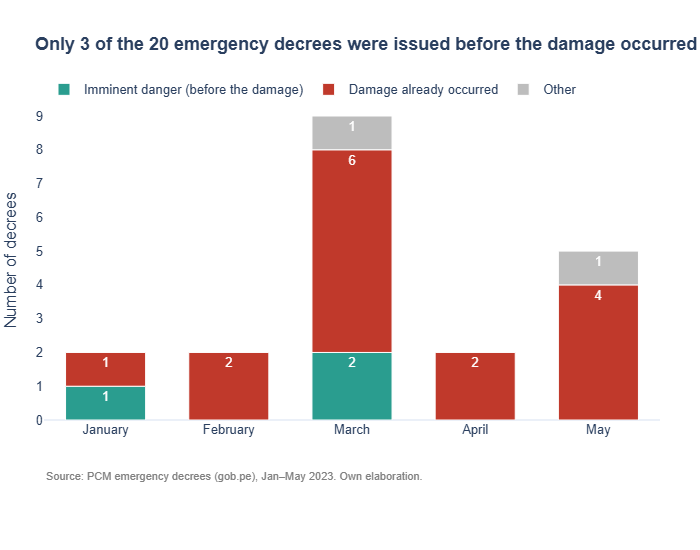

In [34]:
fig = px.bar(por_mes, x="mes", y="decretos", color="motivo_en", text_auto=True,
             category_orders={"mes": list(meses.values()),
                              "motivo_en": list(motivos.values())},
             color_discrete_map={"Imminent danger (before the damage)": "#2a9d8f",
                                 "Damage already occurred": "#c0392b",
                                 "Other": "#bdbdbd"},
             labels={"mes": "", "decretos": "Number of decrees", "motivo_en": ""},
             title="<b>Only 3 of the 20 emergency decrees were issued before the damage occurred</b>",
             height=550)
fig.update_traces(marker_line=dict(width=1, color="white"), textfont_color="white")
fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    bargap=0.35,
    legend=dict(orientation="h", y=1.08, x=0),
    yaxis=dict(showgrid=False, dtick=1),
    margin=dict(l=10, r=40, t=100, b=130),
    annotations=[dict(
        text="Source: PCM emergency decrees (gob.pe), Jan–May 2023. Own elaboration.",
        showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()